###  1. Uvod i cilj istraživanja

U ovom delu projekta sprovodi se *eksploratorna analiza podataka (EDA)* nad skupom podataka
koji se odnosi na indikatore dijabetesa. Cilj je da se:
- razume struktura i distribucija podataka,
- otkriju zanimljive korelacije između varijabli,
- detektuju outlieri pomoću tradicionalnih i neuronskih metoda,

Ovaj deo ima više “data science” akcenat i fokusira se na analitičke uvide.



In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Import tvojih funkcija
from machine_learning.data_loaders.data_loader_prediction import load_diabetes_dataset, preprocess_data

# Učitavanje i osnovni prikaz
df = load_diabetes_dataset(split='train')
print("Dimenzije skupa podataka:", df.shape)
df.head()


Using the latest cached version of the dataset since marianeft/diabetes_prediction_dataset couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\User\.cache\huggingface\datasets\marianeft___diabetes_prediction_dataset\default\0.0.0\2ce23948ea40c0c2facb7e0d520f7255b504165c (last modified on Fri Aug 15 18:36:07 2025).


Dimenzije skupa podataka: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


###  3. Osnovne informacije o podacima

U ovom delu analiziramo osnovne statistike — tipove kolona, broj nedostajućih vrednosti
i deskriptivne mere (srednja vrednost, medijana, varijansa, minimum, maksimum).


In [27]:
df.info()
print("\nBroj nedostajućih vrednosti po kolonama:\n", df.isna().sum())
df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB

Broj nedostajućih vrednosti po kolonama:
 gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000,100000.000000,100000.00000,100000.000000,100000,100000.000000,100000.000000,100000.000000,100000.000000
unique,3,NaN,NaN,NaN,6,NaN,NaN,NaN,NaN
top,Female,NaN,NaN,NaN,No Info,NaN,NaN,NaN,NaN
freq,58552,NaN,NaN,NaN,35816,NaN,NaN,NaN,NaN
mean,NaN,41.885856,0.07485,0.039420,NaN,27.320767,5.527507,138.058060,0.085000
std,NaN,22.516840,0.26315,0.194593,NaN,6.636783,1.070672,40.708136,0.278883
min,NaN,0.080000,0.00000,0.000000,NaN,10.010000,3.500000,80.000000,0.000000
25%,NaN,24.000000,0.00000,0.000000,NaN,23.630000,4.800000,100.000000,0.000000
50%,NaN,43.000000,0.00000,0.000000,NaN,27.320000,5.800000,140.000000,0.000000
75%,NaN,60.000000,0.00000,0.000000,NaN,29.580000,6.200000,159.000000,0.000000


###  4. Vizuelizacija distribucija osnovnih veza

Cilj ove sekcije je da se vizuelno prikažu distribucije numeričkih promenljivih i 
da se uoče potencijalni outlieri, asimetrije i multimodalne distribucije.


<Figure size 1500x1000 with 0 Axes>

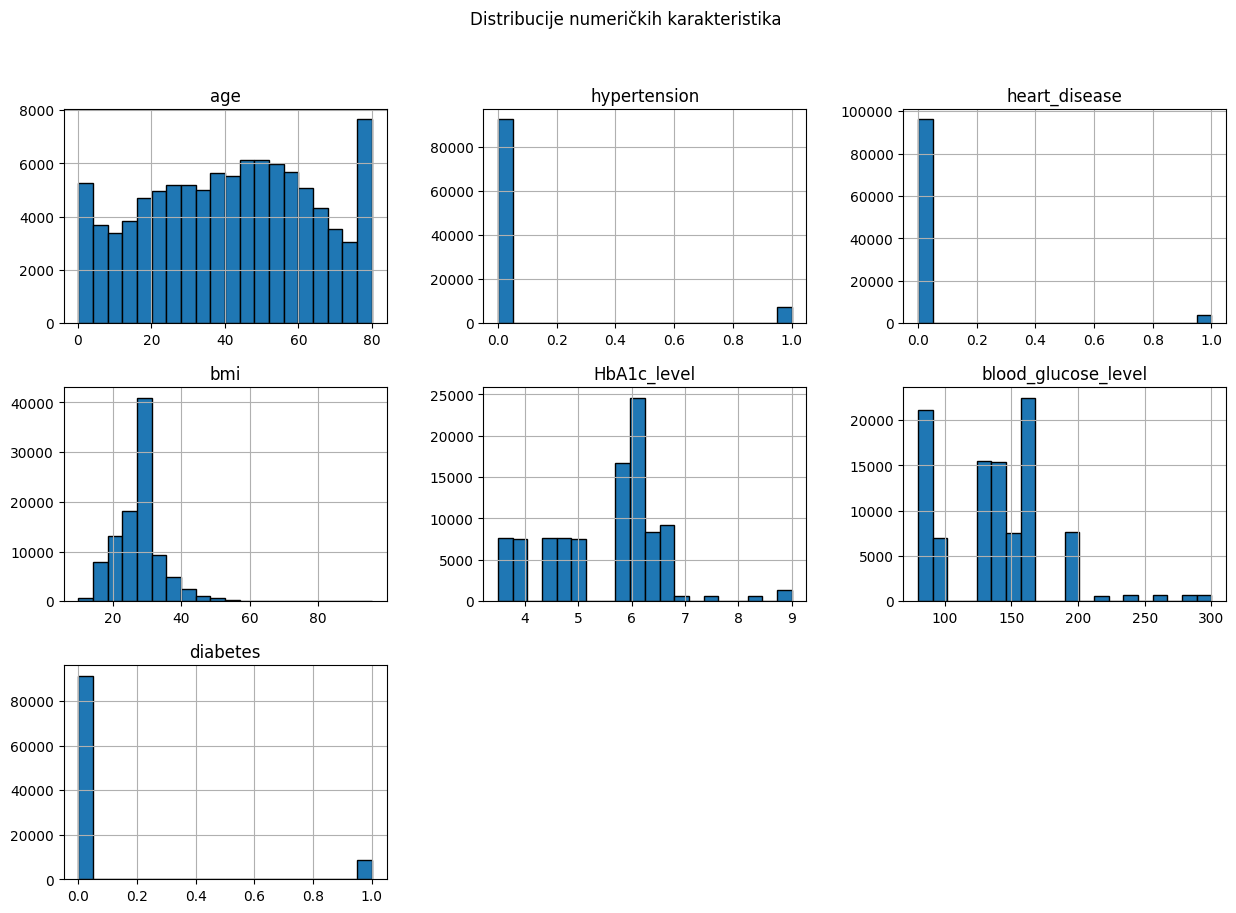

In [28]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(15, 10))
df[numeric_cols].hist(bins=20, figsize=(15,10), edgecolor='black')
plt.suptitle("Distribucije numeričkih karakteristika")
plt.show()


###  5. Korelacije između promenljivih

Ovom analizom posmatramo korelacije između kvantitativnih karakteristika.
Visoka korelacija može ukazivati na redundantne atribute ili važne zavisnosti.



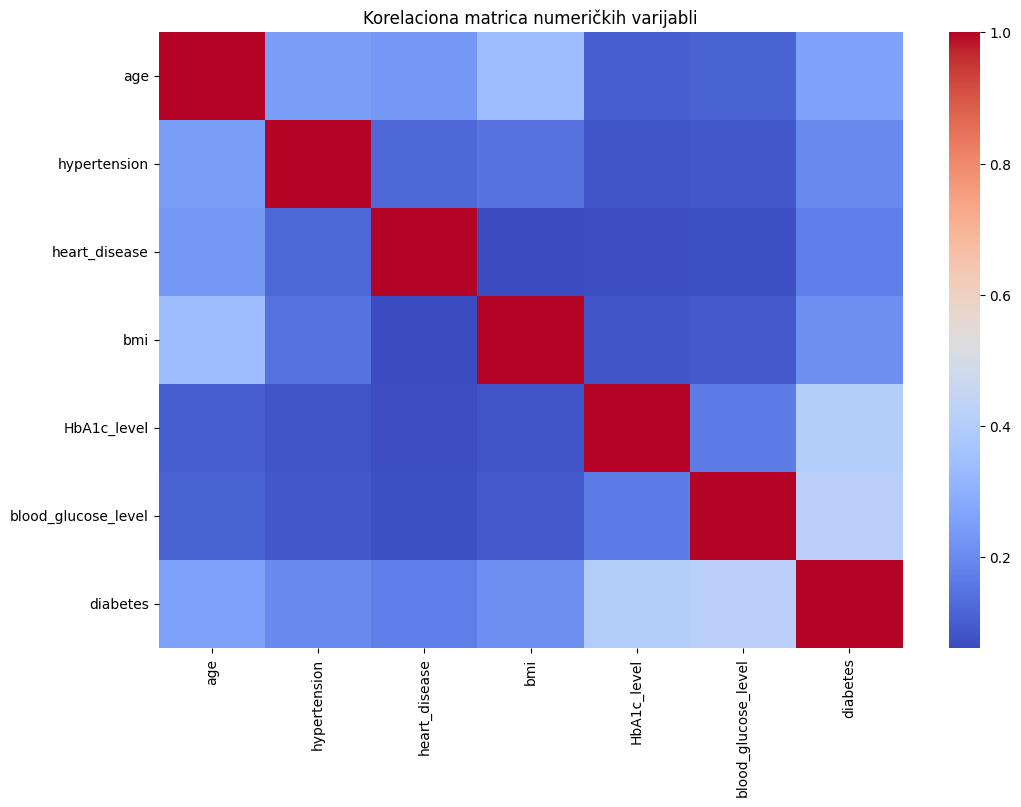

In [29]:
plt.figure(figsize=(12,8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Korelaciona matrica numeričkih varijabli")
plt.show()


###  6. Predprocesiranje i standardizacija podataka

Koristimo već postojeću funkciju preprocess_data() koja vrši mapiranje ordinalnih
vrednosti, imputaciju nedostajućih podataka, skaliranje i one-hot kodiranje.



In [30]:
X_processed, y, preprocessor = preprocess_data(df)
print("Obrađen skup X shape:", X_processed.shape)
print("Target distribucija:\n", y.value_counts(normalize=True))


Obrađen skup X shape: (100000, 15)
Target distribucija:
 diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64


### 7. Detekcija outliera pomoću klasičnih metoda

Koristimo IsolationForest za detekciju ekstremnih slučajeva u podacima.
Ovaj metod koristi ansambl stabala za izolovanje anomalija.



Broj detektovanih outliera (IsolationForest): 5000


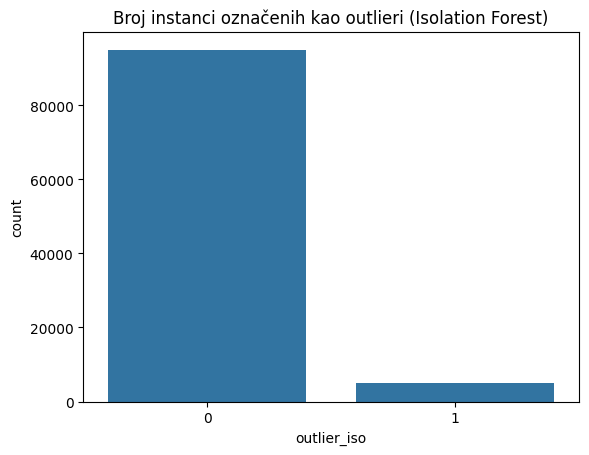

In [31]:
iso = IsolationForest(contamination=0.05, random_state=42)
outlier_flags = iso.fit_predict(X_processed)
df['outlier_iso'] = (outlier_flags == -1).astype(int)

print("Broj detektovanih outliera (IsolationForest):", df['outlier_iso'].sum())
sns.countplot(x='outlier_iso', data=df)
plt.title("Broj instanci označenih kao outlieri (Isolation Forest)")
plt.show()


### 8. Detekcija outliera pomoću MLP autoenkodera

Treniramo višeslojni perceptron (MLP) kao autoenkoder, koji pokušava da rekonstruiše
ulazne podatke. Velika greška rekonstrukcije ukazuje na to da primer nije “tipičan”
i može predstavljati outlier.


Detektovano 5000 outliera pomoću MLP autoenkodera.


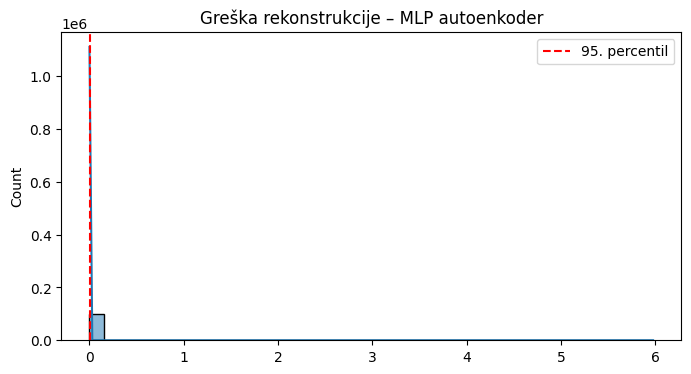

In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_processed)

autoencoder = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32, 64, 128),
    activation='relu',
    solver='adam',
    max_iter=150,
    random_state=42
)

autoencoder.fit(X_scaled, X_scaled)
X_reconstructed = autoencoder.predict(X_scaled)
reconstruction_error = np.mean((X_scaled - X_reconstructed)**2, axis=1)

df['reconstruction_error'] = reconstruction_error
threshold = np.percentile(reconstruction_error, 95)
df['outlier_mlp'] = (reconstruction_error > threshold).astype(int)

print(f"Detektovano {df['outlier_mlp'].sum()} outliera pomoću MLP autoenkodera.")

plt.figure(figsize=(8,4))
sns.histplot(reconstruction_error, bins=40, kde=True)
plt.axvline(threshold, color='red', linestyle='--', label='95. percentil')
plt.title("Greška rekonstrukcije – MLP autoenkoder")
plt.legend()
plt.show()


###  9. Analiza uz pomoć PCA (redukcija dimenzionalnosti)

Primena PCA (Principal Component Analysis) omogućava projekciju podataka u 2D prostor
radi bolje vizuelne interpretacije. Očekuje se da outlieri budu van glavnog oblaka tačaka.


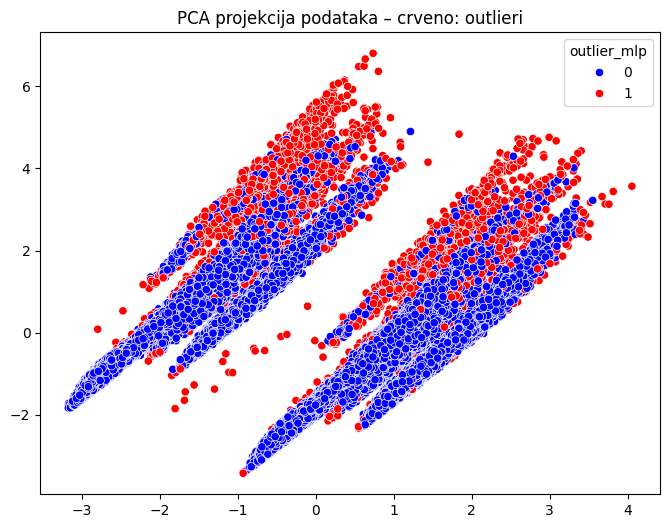

In [33]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['outlier_mlp'], palette=['blue','red'])
plt.title("PCA projekcija podataka – crveno: outlieri")
plt.show()


### Analiza raspodjele ciljnih i ulaznih atributa

U ovoj sekciji analiziramo ciljnu varijablu (`Diabetes_binary`) i distribuciju ulaznih karakteristika.

**Cilj:**
- Provjeriti da li je skup podataka neuravnotežen (tj. da li ima značajno više 0 nego 1).
- Pregledati numeričke i kategorizovane atribute odvojeno.

**Kako čitati rezultate:**
- Bar graf prikazuje broj instanci po klasama — ako postoji velika razlika, model može biti pristrasan.
- Statistički pregled (`describe()`) daje min, max, srednju vrijednost, medijanu i standardnu devijaciju.
- Brojači kategorija omogućavaju uočavanje rijetkih vrijednosti.

C:\Users\User\AppData\Local\Temp\ipykernel_4224\3068084150.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diabetes', data=df, palette='pastel')


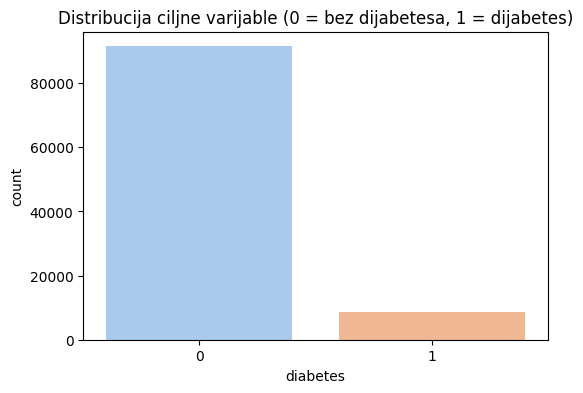

,count,mean,std,min,25%,50%,75%,max
age,100000.0,6.209910,4.233744,0.000000,2.000000,6.00000,10.000000,14.000000
hypertension,100000.0,0.074850,0.263150,0.000000,0.000000,0.00000,0.000000,1.000000
heart_disease,100000.0,0.039420,0.194593,0.000000,0.000000,0.00000,0.000000,1.000000
bmi,100000.0,27.320767,6.636783,10.010000,23.630000,27.32000,29.580000,95.690000
HbA1c_level,100000.0,5.527507,1.070672,3.500000,4.800000,5.80000,6.200000,9.000000
blood_glucose_level,100000.0,138.058060,40.708136,80.000000,100.000000,140.00000,159.000000,300.000000
diabetes,100000.0,0.085000,0.278883,0.000000,0.000000,0.00000,0.000000,1.000000
outlier_iso,100000.0,0.050000,0.217946,0.000000,0.000000,0.00000,0.000000,1.000000
reconstruction_error,100000.0,0.001024,0.053304,0.000016,0.000112,0.00018,0.000339,5.976957
outlier_mlp,100000.0,0.050000,0.217946,0.000000,0.000000,0.00000,0.000000,1.000000



gender:
gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

smoking_history:
smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


In [34]:
# Ciljna distribucija
plt.figure(figsize=(6,4))
sns.countplot(x='diabetes', data=df, palette='pastel')
plt.title("Distribucija ciljne varijable (0 = bez dijabetesa, 1 = dijabetes)")
plt.show()

# Statistike za numeričke kolone
display(df.describe().T)

# Brojači za kategorizovane kolone
cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


### Vizualizacija numeričkih i kategorizovanih karakteristika

**Numeričke:** Histogrami i box-plotovi pokazuju distribuciju i moguće outliere.  
**Kategorizovane:** Bar i pie grafovi prikazuju zastupljenost svake kategorije.

**Kako čitati rezultate:**
- Histogrami otkrivaju oblike distribucija (simetrične, asimetrične, multimodalne).
- Box-plot pokazuje srednju vrijednost (linija u kutiji) i outliere (tačke van brkova).
- Pie graf pokazuje procentualnu zastupljenost kategorija.

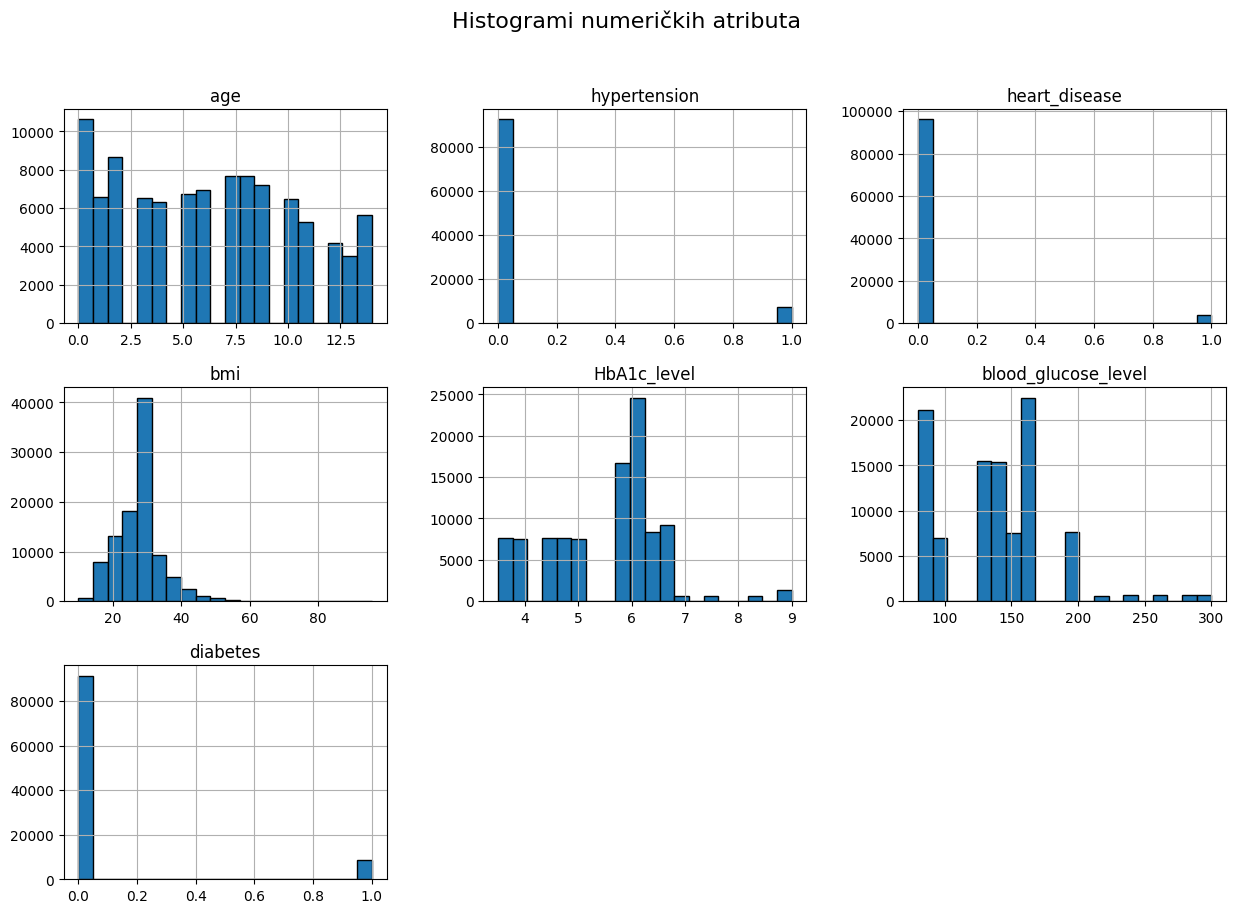

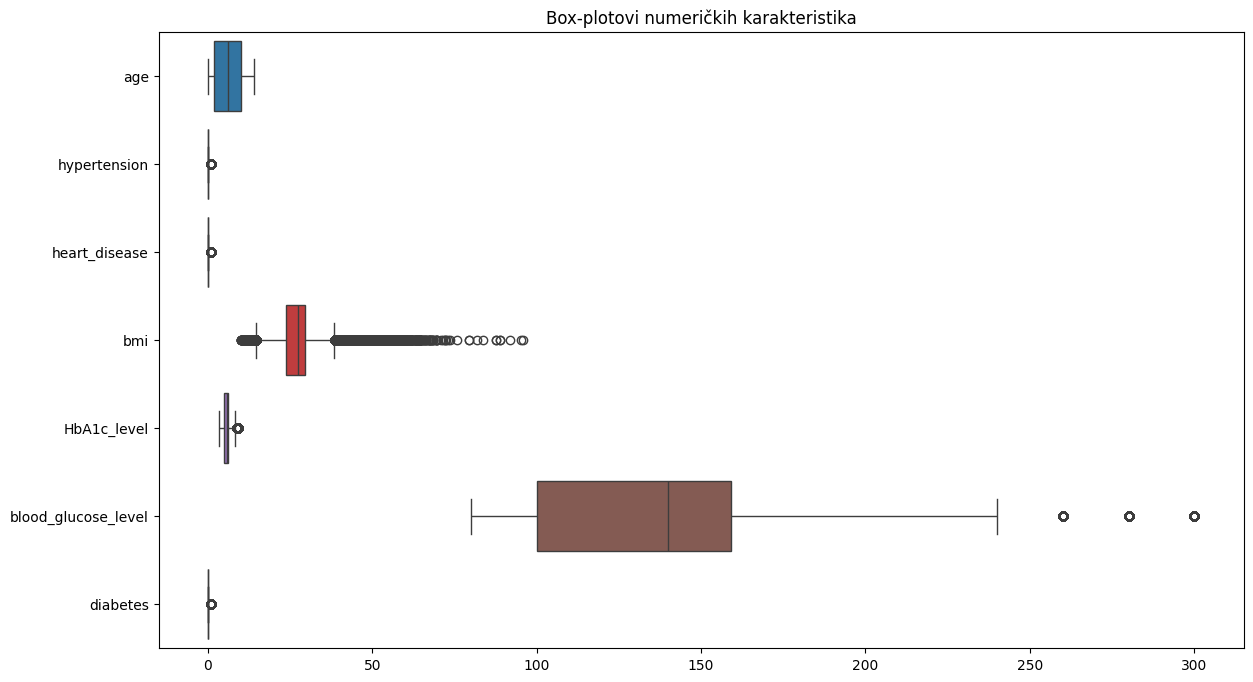

C:\Users\User\AppData\Local\Temp\ipykernel_4224\671540192.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[0], palette="pastel")


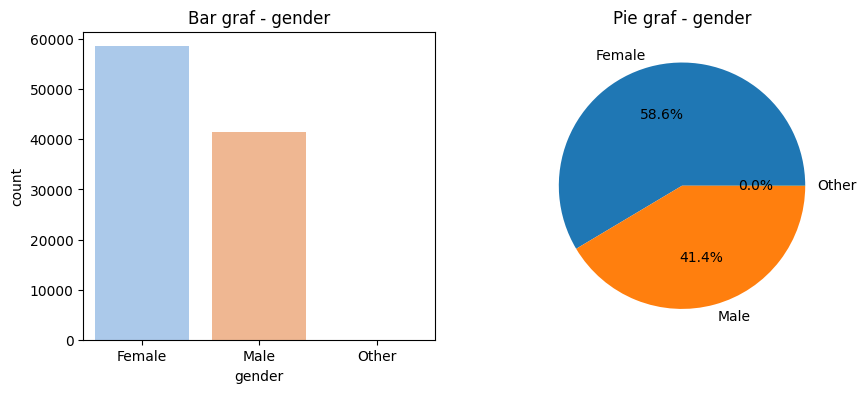

C:\Users\User\AppData\Local\Temp\ipykernel_4224\671540192.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[0], palette="pastel")


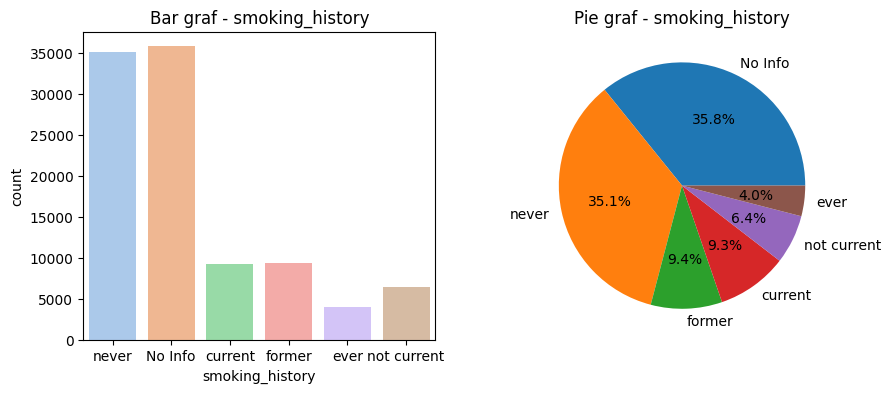

In [35]:
# Histogrami za numeričke kolone
df[numeric_cols].hist(bins=20, figsize=(15,10), edgecolor='black')
plt.suptitle("Histogrami numeričkih atributa", fontsize=16)
plt.show()

# Box-plotovi numeričkih kolona
plt.figure(figsize=(14,8))
sns.boxplot(data=df[numeric_cols], orient='h')
plt.title("Box-plotovi numeričkih karakteristika")
plt.show()

# Bar grafovi i pie chartovi za kategorijske kolone
for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10,4))
    sns.countplot(x=col, data=df, ax=axes[0], palette="pastel")
    axes[0].set_title(f"Bar graf - {col}")
    df[col].value_counts().plot.pie(autopct="%1.1f%%", ax=axes[1])
    axes[1].set_ylabel("")
    axes[1].set_title(f"Pie graf - {col}")
    plt.show()

### Identifikacija outlier-a i nepravilnih vrijednosti

Pored MLP autoenkodera i Isolation Forest-a, koristi se i klasična **IQR metoda**:
- Q1 (25. percentil), Q3 (75. percentil), IQR = Q3 - Q1.
- Sve vrijednosti izvan `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]` tretiraju se kao outlieri.

**Kako čitati rezultate:**
- Ispis pokazuje broj outliera po svakoj numeričkoj koloni.
- Box-plot omogućava vizuelnu identifikaciju ekstremnih vrijednosti.

Broj detektovanih outliera po koloni (IQR metoda):
age: 0
hypertension: 7485
heart_disease: 3942
bmi: 7086
HbA1c_level: 1315
blood_glucose_level: 2038
diabetes: 8500


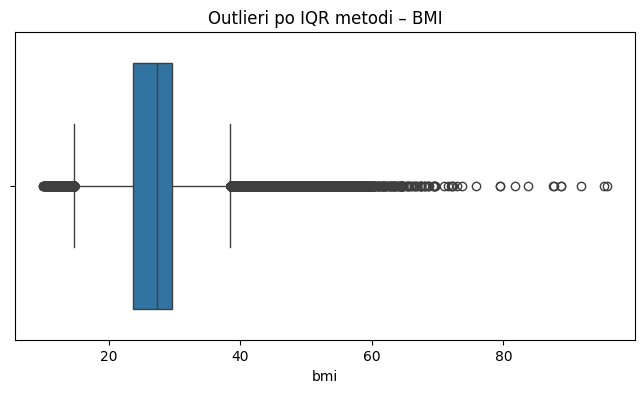

Kategorija 'gender' ima rijetke vrijednosti (<1%):
gender
Other    0.00018
Name: proportion, dtype: float64


In [36]:
iqr_outliers = {}
for col in numeric_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    iqr_outliers[col] = len(outliers)

print("Broj detektovanih outliera po koloni (IQR metoda):")
for k, v in iqr_outliers.items():
    print(f"{k}: {v}")

# Vizuelni pregled jednog primera
plt.figure(figsize=(8,4))
sns.boxplot(x=df['bmi'])
plt.title("Outlieri po IQR metodi – BMI")
plt.show()

# Rijetke kategorije
for col in cat_cols:
    freq = df[col].value_counts(normalize=True)
    rare = freq[freq < 0.01]
    if len(rare) > 0:
        print(f"Kategorija '{col}' ima rijetke vrijednosti (<1%):")
        print(rare)

### Imputacija nedostajućih vrijednosti pomoću MLPRegressora

Umjesto da se redovi s nedostajućim vrijednostima brišu, nedostajući numerički podaci
se predviđaju pomoću neuronske mreže MLPRegressor.

**Kako čitati rezultate:**
- Ispis prikazuje kolone koje imaju nedostajuće vrijednosti i koliki je procenat.
- Nakon imputacije, kolone više ne sadrže NaN vrijednosti.

In [37]:
num_cols = df.select_dtypes(include=[np.number]).columns
missing = df[num_cols].isna().mean()
print("Procenat nedostajućih vrijednosti po koloni:")
print(missing[missing > 0])

# Ako ima nedostajućih vrijednosti
if missing.sum() > 0:
    for col in missing[missing > 0].index:
        temp = df.copy()
        known = temp[temp[col].notna()]
        unknown = temp[temp[col].isna()]
        X_known = known.drop(columns=[col])
        y_known = known[col]
        X_known = pd.get_dummies(X_known, drop_first=True)
        X_known = X_known.fillna(0)
        mlp = MLPRegressor(hidden_layer_sizes=(64,32,16), max_iter=200, random_state=42)
        mlp.fit(X_known, y_known)
        X_unknown = pd.get_dummies(unknown.drop(columns=[col]), drop_first=True)
        X_unknown = X_unknown.reindex(columns=X_known.columns, fill_value=0)
        predicted = mlp.predict(X_unknown)
        df.loc[unknown.index, col] = predicted

print("\nNakon imputacije broj NaN vrijednosti po koloni:")
print(df.isna().sum())

Procenat nedostajućih vrijednosti po koloni:
Series([], dtype: float64)

Nakon imputacije broj NaN vrijednosti po koloni:
gender                  0
age                     0
hypertension            0
heart_disease           0
smoking_history         0
bmi                     0
HbA1c_level             0
blood_glucose_level     0
diabetes                0
outlier_iso             0
reconstruction_error    0
outlier_mlp             0
dtype: int64


### Analiza korelacija (Pearson, Spearman, Chi-Square)

Cilj je identifikovati odnose između atributa i ciljne varijable.

**Pearson:** mjeri linearnu vezu (koristi se za numeričke).  
**Spearman:** mjeri monotoni odnos (takođe za numeričke).  
**Chi-Square:** koristi se za kategorizovane varijable.

**Kako čitati rezultate:**
- Tablice prikazuju najjače korelacije.
- Heatmap omogućava brzu vizuelnu identifikaciju povezanih atributa.

Top 10 Pearson korelacija sa diabetes:
 diabetes                1.000000
blood_glucose_level     0.419558
HbA1c_level             0.400660
outlier_mlp             0.286768
outlier_iso             0.279200
age                     0.261451
bmi                     0.214357
hypertension            0.197823
heart_disease           0.171727
reconstruction_error   -0.000483
Name: diabetes, dtype: float64

Top 10 Spearman korelacija sa Diabetes_binary:
 diabetes                1.000000
HbA1c_level             0.328705
reconstruction_error    0.298196
outlier_mlp             0.286768
outlier_iso             0.279200
blood_glucose_level     0.274217
age                     0.261665
bmi                     0.200061
hypertension            0.197823
heart_disease           0.171727
Name: diabetes, dtype: float64

Chi-Square test za gender: p-vrijednost = 0.0000

Chi-Square test za smoking_history: p-vrijednost = 0.0000


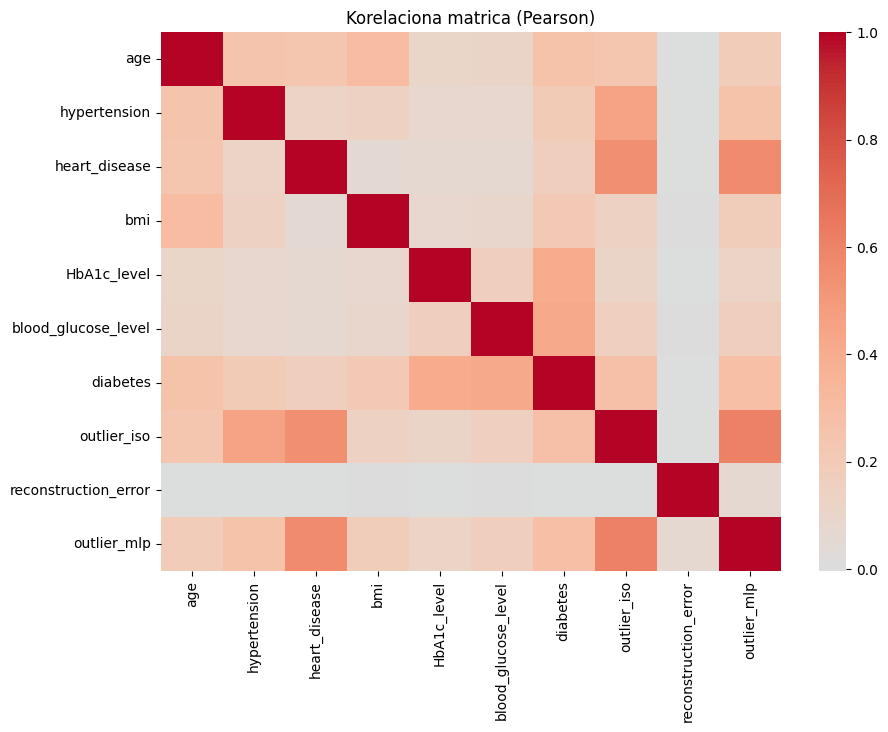

In [38]:
from scipy.stats import spearmanr, chi2_contingency

# Pearson
pearson_corr = df.corr(numeric_only=True)['diabetes'].sort_values(ascending=False)
print("Top 10 Pearson korelacija sa diabetes:\n", pearson_corr.head(10))

# Spearman
spearman_corr = df.corr(method='spearman', numeric_only=True)['diabetes'].sort_values(ascending=False)
print("\nTop 10 Spearman korelacija sa Diabetes_binary:\n", spearman_corr.head(10))

# Chi-Square za kategorijske
for col in cat_cols:
    contingency = pd.crosstab(df[col], df['diabetes'])
    chi2, p, _, _ = chi2_contingency(contingency)
    print(f"\nChi-Square test za {col}: p-vrijednost = {p:.4f}")

# Heatmap
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title("Korelaciona matrica (Pearson)")
plt.show()

### Vizualizacija istraživačkih pitanja

**Cilj:** Uočiti veze između ključnih faktora rizika i dijabetesa.

**Vizualizacije uključuju:**
- Starosna grupa vs. BMI – scatter i box-plot.
- Pušenje, hipertenzija i srčane bolesti – grupisani i stacked bar grafovi.
- Višedimenzionalni odnosi – pairplot.
- Distribucija po klasama (dijabetičari / nedijabetičari) – violin plot.

C:\Users\User\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


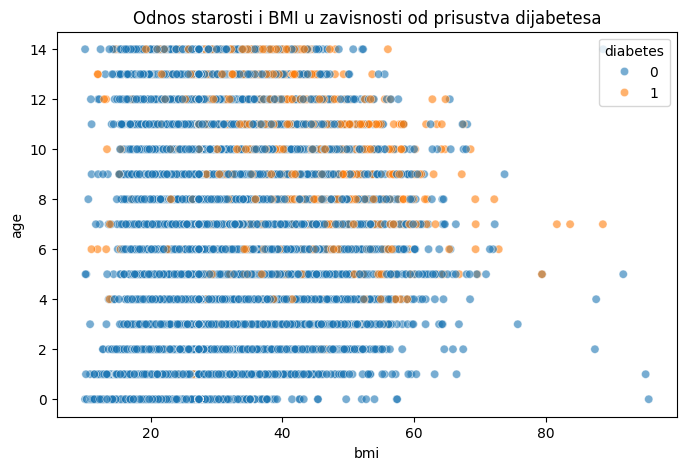

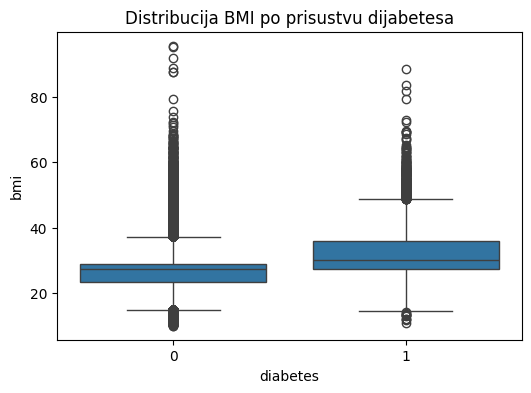

ValueError: Could not interpret value `Smoker` for `x`. An entry with this name does not appear in `data`.

<Figure size 600x400 with 0 Axes>

In [39]:
# Scatter BMI vs. starost
plt.figure(figsize=(8,5))
sns.scatterplot(x='bmi', y='age', hue='diabetes', data=df, alpha=0.6)
plt.title("Odnos starosti i BMI u zavisnosti od prisustva dijabetesa")
plt.show()

# Box-plot BMI po dijabetes statusu
plt.figure(figsize=(6,4))
sns.boxplot(x='diabetes', y='bmi', data=df)
plt.title("Distribucija BMI po prisustvu dijabetesa")
plt.show()

# Grupisani bar graf (pušenje, visok pritisak, srčane bolesti)
factors = ['Smoker', 'HighBP', 'HeartDisease']
for f in factors:
    plt.figure(figsize=(6,4))
    sns.countplot(x=f, hue='diabetes', data=df)
    plt.title(f"Distribucija dijabetesa po faktoru: {f}")
    plt.show()
# Violin plot za poređenje numeričkih vrijednosti
plt.figure(figsize=(8,6))
sns.violinplot(x='diabetes', y='PhysHlth', data=df)
plt.title("Distribucija PhysHlth po dijabetes statusu")
plt.show()

# Pairplot – višedimenzionalni uvid
sns.pairplot(df, vars=['BMI', 'Age', 'PhysHlth', 'MentHlth'], hue='diabetes', diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle("Pairplot: višedimenzionalni odnosi numeričkih varijabli", y=1.02)
plt.show()

### Zaključci iz EDA faze

1. Skup podataka pokazuje **umerenu neuravnoteženost** između klasa, što treba imati u vidu prilikom treniranja modela.
2. Identifikovane su značajne varijable sa visokom korelacijom prema cilju (npr. BMI, HighBP, PhysHlth).
3. Klasične (IQR) i neuronske metode (MLP autoenkoder) dosledno ukazuju na prisustvo outliera, naročito u fiziološkim mjerama.
4. Detektovane su rijetke kategorije kod nekih atributa koje će zahtijevati kodiranje ili spajanje.
5. Imputacija pomoću MLPRegressora uspješno popunjava nedostajuće vrijednosti bez gubitka instanci.
6. Analiza odnosa između zdravstvenih faktora i dijabetesa potvrđuje očekivane obrasce (veći BMI i pritisak kod oboljelih).
7. Ova EDA faza čini osnovu za informisano modelovanje, odabir atributa i evaluaciju performansi neuronskih mreža u narednim koracima.